# **EJ1_Pandas_FernandezBecerra_Alvaro**

# 1. Carga los datos, exploralos y muestra informacion representativa de los mismos.

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
# Cargar datos, explorar y mostrar info

df = pd.read_csv('students.csv')

# Podemos listar las primeras filas con lo que podremos ver como esta organizado, nombres de columnas...
df.head(5)


,Certification Course,Gender,Department,Height(CM),Weight(KG),10th Mark,12th Mark,college mark,hobbies,daily studing time,prefer to study in,salary expectation,Do you like your degree?,willingness to pursue a career based on their degree,social medai & video,Travelling Time,Stress Level,Financial Status,part-time job
0,No,Male,BCA,100.0,58.0,79.0,64.0,80.0,Video Games,0 - 30 minute,Morning,40000,No,50%,1.30 - 2 hour,30 - 60 minutes,Bad,Bad,No
1,No,Female,BCA,90.0,40.0,70.0,80.0,70.0,Cinema,30 - 60 minute,Morning,15000,Yes,75%,1 - 1.30 hour,0 - 30 minutes,Bad,Bad,No
2,Yes,Male,BCA,159.0,78.0,71.0,61.0,55.0,Cinema,1 - 2 Hour,Anytime,13000,Yes,50%,More than 2 hour,30 - 60 minutes,Awful,Bad,No
3,Yes,Female,BCA,147.0,20.0,70.0,59.0,58.0,Reading books,1 - 2 Hour,Anytime,1500000,No,50%,1.30 - 2 hour,0 - 30 minutes,Bad,good,No
4,No,Male,BCA,170.0,54.0,40.0,65.0,30.0,Video Games,30 - 60 minute,Morning,50000,Yes,25%,1.30 - 2 hour,30 - 60 minutes,Good,good,No


- Con `describe()` podemos analizar las columnas numericas. Cantidad de registros, valores maximos y minimos, valor medio...
Comprobamos que hay 235 registros.

In [71]:
df.describe()

,Height(CM),Weight(KG),10th Mark,12th Mark,college mark,salary expectation
count,235.000000,235.000000,235.000000,235.000000,235.000000,2.350000e+02
mean,157.402128,60.803830,76.848511,68.775872,70.660553,3.248168e+04
std,21.510805,14.895844,13.047560,11.018192,15.727446,1.113146e+05
min,4.500000,20.000000,7.400000,45.000000,1.000000,0.000000e+00
25%,152.000000,50.000000,70.000000,60.000000,60.000000,1.500000e+04
50%,160.000000,60.000000,80.000000,69.000000,70.000000,2.000000e+04
75%,170.000000,70.000000,86.250000,76.000000,80.000000,2.500000e+04
max,192.000000,106.000000,98.000000,94.000000,100.000000,1.500000e+06


# 2. Revisa si hay nulos. Cuántos hay por cada columna? Eliminar las que no necesites.

- Haciendo una suma de valores nulos por columna vemos que no hay nulos.

Esto hace que no debamos preocuparnos por ellos pero podemos eliminar columnas que no necesitemos.

In [72]:
df.isnull().sum()

Certification Course                                      0
Gender                                                    0
Department                                                0
Height(CM)                                                0
Weight(KG)                                                0
10th Mark                                                 0
12th Mark                                                 0
college mark                                              0
hobbies                                                   0
daily studing time                                        0
prefer to study in                                        0
salary expectation                                        0
Do you like your degree?                                  0
willingness to pursue a career based on their degree      0
social medai & video                                      0
Travelling Time                                           0
Stress Level                            

- Habiendo revisado las columnas que van a ser necesarias para todo el estudio, voy a eliminar todas las que no vayan a ser usadas.

In [73]:
df = df.drop(columns=['Height(CM)','Weight(KG)','10th Mark','12th Mark','hobbies','prefer to study in','salary expectation',
                    'Do you like your degree?','willingness to pursue a career based on their degree  ','social medai & video',
                    'Travelling Time ','Financial Status','part-time job'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Certification Course  235 non-null    str    
 1   Gender                235 non-null    str    
 2   Department            235 non-null    str    
 3   college mark          235 non-null    float64
 4   daily studing time    235 non-null    str    
 5   Stress Level          235 non-null    str    
dtypes: float64(1), str(5)
memory usage: 11.1 KB


# 3. Encuentra y muestra los 10 estudiantes con mayores calificaciones 'college mark' en la universidad. Imprime sus datos principales


- Voy a crear otro dataframe a partir del primero ordenando los valores por `college mark` de forma descendende y quedandome solo con los 10 primeros registros con `head(10)`

In [74]:
df_calificaciones = df.sort_values('college mark', ascending=False).head(10)
# Mostramos el dataframe:
df_calificaciones

,Certification Course,Gender,Department,college mark,daily studing time,Stress Level
214,Yes,Female,Commerce,100.0,1 - 2 Hour,Good
224,Yes,Female,Commerce,100.0,3 - 4 hour,Good
159,Yes,Male,Commerce,97.0,0 - 30 minute,fabulous
225,Yes,Female,Commerce,95.0,2 - 3 hour,Good
59,Yes,Male,B.com Accounting and Finance,95.0,3 - 4 hour,Bad
58,Yes,Female,Commerce,93.0,1 - 2 Hour,Good
176,No,Female,Commerce,92.8,3 - 4 hour,Good
55,No,Male,Commerce,92.0,30 - 60 minute,fabulous
170,Yes,Female,Commerce,91.0,1 - 2 Hour,Good
62,Yes,Male,Commerce,90.0,More Than 4 hour,Awful


# 4. Cuantos departamentos diferentes hay? Imprime cuantos y cuales. Calcula y muestra la frecuencia de alumnos que hay en ellos.

- Agrupamos con `groupby`. Además, mostramos el tamaño `size()` o numero de registros

- Vemos que hay **4** departamentos diferentes. El que menos alumnos tiene es 'B.com Accounting and Finance' con 15 alumnos y el que más 'BCA' con 132 alumnos.

In [75]:
print(df.groupby('Department').size())

Department
B.com Accounting and Finance      15
B.com ISM                         28
BCA                              132
Commerce                          60
dtype: int64


# 5. Calcula y muestra la media de las calificaciones por departamento y genero.

- Aqui debemos usar de nuevo la agrupación con `groupby()`. Despues sobre las calificaciones calculamos la media con `mean()`

In [76]:
# Media por departamento
media_departamento = df.groupby(['Department','Gender'])['college mark'].mean().sort_values(ascending=False)
print(f'- MEDIA POR DEPARTAMENTO -\n{media_departamento}')

- MEDIA POR DEPARTAMENTO -
Department                     Gender
Commerce                       Female    82.406897
BCA                            Female    77.026316
Commerce                       Male      74.419355
B.com Accounting and Finance   Male      68.666667
BCA                            Male      67.047128
B.com Accounting and Finance   Female    66.833333
B.com ISM                      Male      59.318182
                               Female    59.166667
Name: college mark, dtype: float64


# 6. Agrupar estudiantes por nivel de estres y calcular mediana de sus calificaciones

- Casi igual que el apaartado anterior simplemente cambiando la agrupación y usando `median()` en vez de `mean()`.

In [77]:
# Mediana por estres
mediana_estres = df.groupby('Stress Level ')['college mark'].median().sort_values(ascending=False)
print(f'- MEDIANA POR DEPARTAMENTO -\n{mediana_estres}')

- MEDIANA POR DEPARTAMENTO -
Stress Level 
fabulous    75.0
Good        75.0
Bad         70.0
Awful       70.0
Name: college mark, dtype: float64


# 7. Representar la frecuencia de cada nvl de estres en un grafico de barras

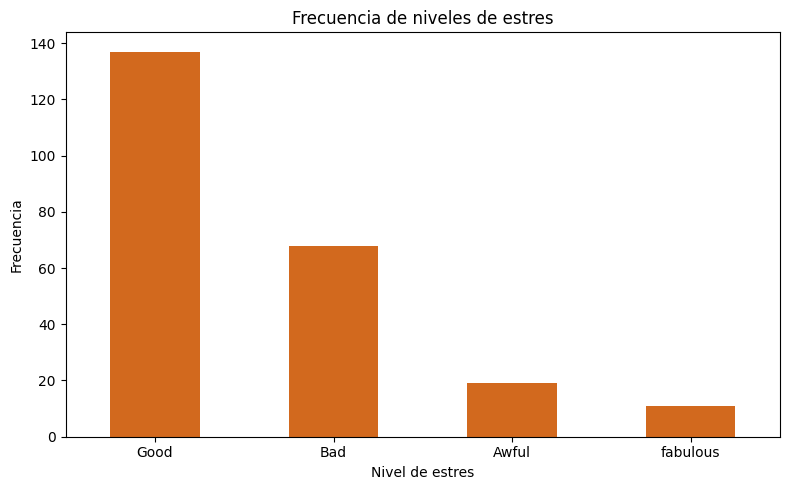

In [78]:
plt.figure(figsize=(8, 5))
df.groupby('Stress Level ').size().sort_values(ascending=False).plot(kind='bar', color='chocolate')
plt.title('Frecuencia de niveles de estres')
plt.xlabel('Nivel de estres')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. Representa un grafico de dispersion la relacion entre el tiempo de estudio y la calificacion obtenida.


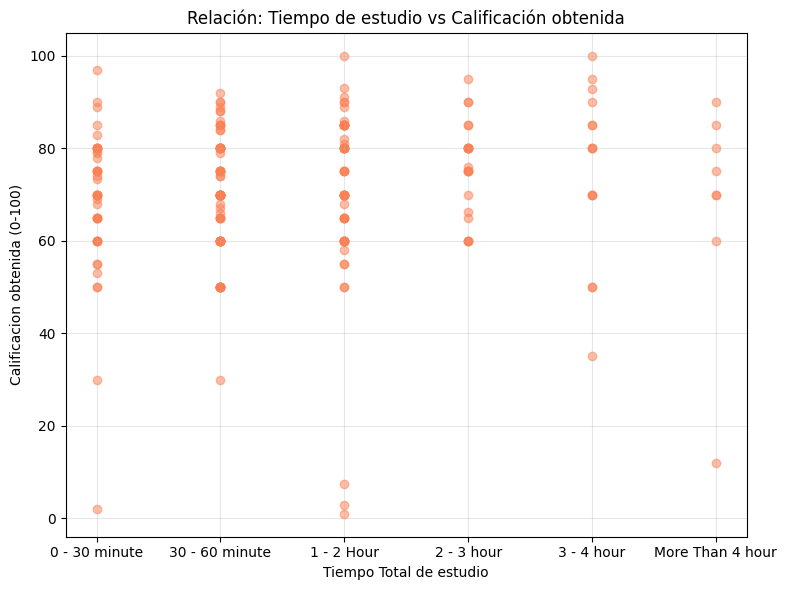

In [79]:
plt.figure(figsize=(8, 6))
plt.scatter(df['daily studing time'], df['college mark'], alpha=0.5, c='coral')
plt.title('Relación: Tiempo de estudio vs Calificación obtenida')
plt.xlabel('Tiempo Total de estudio')
plt.ylabel('Calificacion obtenida (0-100)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dispersion_tiempo_datos.png')
plt.show()

- Como analisis final, se observa que el rango total de estudio en el que estaría la mayoria de alumnos que sacan notas medias sería de 0 a 2 horas. Quizás cogiendo también hasta 3 horas.

- En casi todos los rangos se ven valores extremos, más a la baja que hacia arriba, menos el rango de **2-3 horas** que es el que menos dispersión tiene.

Como observación que sorprende parece ser que dedicarle demasiado tiempo de estudio, en este caso concreto, es contraproducente. 

La mayor calificación obtenida por alguien que dedicó mas de 4 horas de estudio no es siquiera la mayor calificación obtenida en el resto de rangos.                         Incluso, hay un registro suspenso de una persona que dedicó más de 4 horas a estudiar.